# CA1 -> Interneurons -> PFC L5/L6 model
Network logic:
- CA1 pyramidal cells receive an external delayed IClamp stimulus.
- CA1 excites interneurons.
- Interneurons inhibit PFC L5 and PFC L6 pyramidal cells.
- L5 and L6 are connected with weak excitatory recurrent/cross-layer connections.
- Baseline activity is stochastic and reproducible; after CA1 activation, interneurons increase firing and PFC L5/L6 are transiently suppressed.


## Imports

In [2]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

from netpyne import specs, sim
from neuron import h

# Run correctly whether the notebook is opened from the repository root or from ./sim.
cwd = Path.cwd()
if (cwd / 'sim').exists():
    repo_dir = cwd
    sim_dir = cwd / 'sim'
elif cwd.name == 'sim':
    sim_dir = cwd
    repo_dir = cwd.parent
else:
    raise FileNotFoundError(f"Could not find the repository sim directory from {cwd}")

os.chdir(sim_dir)
print('Working directory:', Path.cwd())

# Reuse the compiled mechanisms already present in this repository.
mech_lib = sim_dir / 'x86_64' / 'libnrnmech.so'
if mech_lib.exists():
    try:
        h.nrn_load_dll(str(mech_lib))
        print('Loaded mechanisms:', mech_lib)
    except Exception as exc:
        print('Mechanisms may already be loaded:', exc)
else:
    print('No compiled mechanism library found. If mechanisms fail, run: nrnivmodl mod_combined')

Working directory: /mnt/E45C26F25C26BEE4/DOCTORADO/CODIGOS/Math_model/CA1_mPFC_TC-main/sim
Loaded mechanisms: /mnt/E45C26F25C26BEE4/DOCTORADO/CODIGOS/Math_model/CA1_mPFC_TC-main/sim/x86_64/libnrnmech.so


## Simulation Configuration

In [3]:
netParams = specs.NetParams()
cfg = specs.SimConfig()

# A 700 ms simulation gives baseline, stimulus response, L5 recovery, and longer L6 recovery.
cfg.duration = 1000.0
cfg.dt = 0.025
cfg.hParams = {'celsius': 34, 'v_init': -65}
cfg.verbose = True
cfg.createNEURONObj = True
cfg.createPyStruct = True
cfg.cvode_active = False
cfg.recordStep = 0.05
cfg.recordTraces = {}
cfg.recordCells = []
cfg.filename = 'CA1_INT_L5_L6_model'
cfg.savePickle = True
cfg.saveJson = False

netParams.defaultThreshold = -10.0
netParams.defaultDelay = 0.1

stim_time_ms = 300.0
ca1_stim_duration_ms = 0.2
rng_seed = 4321
rng = np.random.default_rng(rng_seed)

# Approximate post-stimulus suppression windows used for plotting and analysis.
# l5_silence_window = (stim_time_ms + 20.0, stim_time_ms + 70.0)
# l6_silence_window = (stim_time_ms + 20.0, stim_time_ms + 70.0)

pop_order = ['CA1_Pyr', 'Interneurons_L5', 'Interneurons_L6', 'PFC_L5_Pyr', 'PFC_L6_Pyr']

## Cell Rule Loading

In [4]:
def clean_loaded_rule(raw_label, file_name, new_label):
    """Load a NetPyNE cell rule and normalize its label/section lists."""
    netParams.loadCellParamsRule(label=raw_label, fileName=file_name)
    raw = netParams.cellParams.pop(raw_label)
    secs = raw['secs']
    sec_lists = dict(raw.get('secLists', {}))
    sec_lists.setdefault('all', list(secs.keys()))
    sec_lists.setdefault('basal', [sec for sec in secs if 'dend' in sec.lower()])
    sec_lists.setdefault('apical', [sec for sec in secs if 'apic' in sec.lower()])
    sec_lists.setdefault('somatic', [sec for sec in secs if 'soma' in sec.lower()])
    netParams.cellParams[new_label] = {
        'conds': {
            'cellType': new_label,
            'cellModel': raw.get('conds', {}).get('cellModel', 'HH_full')
        },
        'secs': secs,
        'secLists': sec_lists
    }


def detect_soma(rule_label):
    """Choose the soma section used for IClamp and simple synaptic inputs."""
    rule = netParams.cellParams[rule_label]
    somatic = rule.get('secLists', {}).get('somatic', [])
    if somatic:
        return somatic[0]
    for sec in rule['secs']:
        if 'soma' in sec.lower():
            return sec
    return next(iter(rule['secs']))

# Same cell parameter files as the reference notebook.
clean_loaded_rule('CA1_raw', 'cells/poolosyncell_cellParams.pkl', 'CA1_PYR_cell')
clean_loaded_rule('INH_LBC_raw', 'cells/L5_LBC_cACint209_1_cellParams.json', 'PFC_INH_LBC_cell')
clean_loaded_rule('INH_MC_raw', 'cells/L6_MC_cACint209_1_cellParams.json', 'PFC_INH_MC_cell')
clean_loaded_rule('PFC_L5_raw', 'cells/L5_TTPC1_cADpyr232_1_cellParams.json', 'PFC_L5_PYR_cell')
clean_loaded_rule('PFC_L6_raw', 'cells/L6_TPC_L1_cADpyr231_1_cellParams.json', 'PFC_L6_PYR_cell')

ca1_soma_sec = detect_soma('CA1_PYR_cell')
inh_l5_soma_sec = detect_soma('PFC_INH_LBC_cell')
inh_l6_soma_sec = detect_soma('PFC_INH_MC_cell')
pfc_l5_soma_sec = detect_soma('PFC_L5_PYR_cell')
pfc_l6_soma_sec = detect_soma('PFC_L6_PYR_cell')

print('CA1 soma section:', ca1_soma_sec)
print('Interneuron L5 soma section:', inh_l5_soma_sec)
print('Interneuron L6 soma section:', inh_l6_soma_sec)
print('PFC L5 pyramidal soma section:', pfc_l5_soma_sec)
print('PFC L6 pyramidal soma section:', pfc_l6_soma_sec)

CA1 soma section: soma_0
Interneuron L5 soma section: soma
Interneuron L6 soma section: soma
PFC L5 pyramidal soma section: soma
PFC L6 pyramidal soma section: soma


## Population Definitions

In [5]:
netParams.popParams['CA1_Pyr'] = {
    'cellType': 'CA1_PYR_cell',
    'cellModel': netParams.cellParams['CA1_PYR_cell']['conds']['cellModel'],
    'numCells': 5
}

netParams.popParams['Interneurons_L5'] = {
    'cellType': 'PFC_INH_LBC_cell',
    'cellModel': netParams.cellParams['PFC_INH_LBC_cell']['conds']['cellModel'],
    'numCells': 5
}

netParams.popParams['Interneurons_L6'] = {
    'cellType': 'PFC_INH_MC_cell',
    'cellModel': netParams.cellParams['PFC_INH_MC_cell']['conds']['cellModel'],
    'numCells': 5
}

netParams.popParams['PFC_L5_Pyr'] = {
    'cellType': 'PFC_L5_PYR_cell',
    'cellModel': netParams.cellParams['PFC_L5_PYR_cell']['conds']['cellModel'],
    'numCells': 10
}

netParams.popParams['PFC_L6_Pyr'] = {
    'cellType': 'PFC_L6_PYR_cell',
    'cellModel': netParams.cellParams['PFC_L6_PYR_cell']['conds']['cellModel'],
    'numCells': 10
}

## Synaptic Mechanism Definitions

In [6]:
# Fast excitation from CA1, background inputs, and L5/L6 cross-layer communication.
netParams.synMechParams['AMPA_CA1_INT'] = {'mod': 'Exp2Syn', 'tau1': 0.2, 'tau2': 1.7, 'e': 0}
netParams.synMechParams['AMPA_BG'] = {'mod': 'Exp2Syn', 'tau1': 0.2, 'tau2': 1.7, 'e': 0}
netParams.synMechParams['AMPA_L5_L6'] = {'mod': 'Exp2Syn', 'tau1': 0.2, 'tau2': 1.7, 'e': 0}

# Interneurons inhibit both PFC pyramidal populations.
netParams.synMechParams['GABA_INT_PFC'] = {'mod': 'Exp2Syn', 'tau1': 0.3, 'tau2': 8.3, 'e': -82}

## Connectivity Rules

In [7]:
# Set weight and probability constants
# CA1 to interneurons
w_CA1_INT_L5 = 0.14
p_CA1_INT_L5 = 0.45

w_CA1_INT_L6 = 0.09
p_CA1_INT_L6 = 0.45

# Interneurons to PFC pyramidal cells
w_INT_L5_PFC_L5 = 0.35
p_INT_L5_PFC_L5 = 0.35

w_INT_L5_PFC_L6 = 0.45
p_INT_L5_PFC_L6 = 0.45

w_INT_L6_PFC_L5 = 0.35
p_INT_L6_PFC_L5 = 0.35

w_INT_L6_PFC_L6 = 0.45
p_INT_L6_PFC_L6 = 0.45

# Weak excitatory communication between L5 and L6 is included explicitly.
w_PFC_L5_L6 = 0.0012 # 0.00035
p_PFC_L5_L6 = 0.06 # 0.15

w_PFC_L6_L5 = 0.0010
p_PFC_L6_L5 = 0.06 # 0.10

# CA1 activation excites interneurons.
netParams.connParams['CA1_Pyr_to_Interneurons_L5'] = {
    'preConds': {'pop': 'CA1_Pyr'},
    'postConds': {'pop': 'Interneurons_L5'},
    'probability': p_CA1_INT_L5,
    'weight': w_CA1_INT_L5,
    'delay': 4.0,
    'synMech': 'AMPA_CA1_INT',
    'sec': inh_l5_soma_sec,
    'loc': 0.5,
    'synsPerConn': 2
}

netParams.connParams['CA1_Pyr_to_Interneurons_L6'] = {
    'preConds': {'pop': 'CA1_Pyr'},
    'postConds': {'pop': 'Interneurons_L6'},
    'probability': p_CA1_INT_L6,
    'weight': w_CA1_INT_L6,
    'delay': 4.0,
    'synMech': 'AMPA_CA1_INT',
    'sec': inh_l6_soma_sec,
    'loc': 0.5,
    'synsPerConn': 2
}


# Interneurons suppress L5 and L6 pyramidal activity after they are recruited by CA1.
netParams.connParams['Interneurons_L5_to_PFC_L5_Pyr'] = {
    'preConds': {'pop': 'Interneurons_L5'},
    'postConds': {'pop': 'PFC_L5_Pyr'},
    'probability': p_INT_L5_PFC_L5,
    'weight': w_INT_L5_PFC_L5,
    'delay': 1.5,
    'synMech': 'GABA_INT_PFC',
    'sec': pfc_l5_soma_sec,
    'loc': 0.5,
    'synsPerConn': 2
}

netParams.connParams['Interneurons_L5_to_PFC_L6_Pyr'] = {
    'preConds': {'pop': 'Interneurons_L5'},
    'postConds': {'pop': 'PFC_L6_Pyr'},
    'probability': p_INT_L5_PFC_L6,
    'weight': w_INT_L5_PFC_L6,
    'delay': 1.5,
    'synMech': 'GABA_INT_PFC',
    'sec': pfc_l6_soma_sec,
    'loc': 0.5,
    'synsPerConn': 2
}

netParams.connParams['Interneurons_L6_to_PFC_L5_Pyr'] = {
    'preConds': {'pop': 'Interneurons_L6'},
    'postConds': {'pop': 'PFC_L5_Pyr'},
    'probability': p_INT_L6_PFC_L5,
    'weight': w_INT_L6_PFC_L5,
    'delay': 1.5,
    'synMech': 'GABA_INT_PFC',
    'sec': pfc_l5_soma_sec,
    'loc': 0.5,
    'synsPerConn': 2
}


netParams.connParams['Interneurons_L6_to_PFC_L6_Pyr'] = {
    'preConds': {'pop': 'Interneurons_L6'},
    'postConds': {'pop': 'PFC_L6_Pyr'},
    'probability': p_INT_L6_PFC_L6,
    'weight': w_INT_L6_PFC_L6,
    'delay': 1.5,
    'synMech': 'GABA_INT_PFC',
    'sec': pfc_l6_soma_sec,
    'loc': 0.5,
    'synsPerConn': 2
}

# Weak excitatory communication between L5 and L6 is included explicitly.
netParams.connParams['PFC_L5_Pyr_to_PFC_L6_Pyr'] = {
    'preConds': {'pop': 'PFC_L5_Pyr'},
    'postConds': {'pop': 'PFC_L6_Pyr'},
    'probability': p_PFC_L5_L6,
    'weight': w_PFC_L5_L6,
    'delay': 2.5,
    'synMech': 'AMPA_L5_L6',
    'sec': pfc_l6_soma_sec,
    'loc': 0.5,
    'synsPerConn': 1
}

netParams.connParams['PFC_L6_Pyr_to_PFC_L5_Pyr'] = {
    'preConds': {'pop': 'PFC_L6_Pyr'},
    'postConds': {'pop': 'PFC_L5_Pyr'},
    'probability': p_PFC_L6_L5,
    'weight': w_PFC_L6_L5,
    'delay': 3.0,
    'synMech': 'AMPA_L5_L6',
    'sec': pfc_l5_soma_sec,
    'loc': 0.5,
    'synsPerConn': 1
}

## Stimulus Definitions

In [8]:

# ------------------------------------------------------------
#    Moderate baseline drives
# ------------------------------------------------------------

def get_num_cells(pop):
    """Return number of cells in a NetPyNE population."""
    return int(netParams.popParams[pop].get('numCells', 0))


# def make_per_cell_list(mean, sd, n, min_val=0.0, max_val=None):
#     """Generate heterogeneous per-cell values."""
#     vals = rng.normal(mean, sd, n)
#     vals = np.maximum(vals, min_val)
#     if max_val is not None:
#         vals = np.minimum(vals, max_val)
#     return vals.tolist()


#   Number of cells per population

n_CA1    = get_num_cells('CA1_Pyr')
n_INT_L5 = get_num_cells('Interneurons_L5')
n_INT_L6 = get_num_cells('Interneurons_L6')
n_PFC_L5 = get_num_cells('PFC_L5_Pyr')
n_PFC_L6 = get_num_cells('PFC_L6_Pyr')


drive_params = {
    'CA1_Pyr': {
        'sec': ca1_soma_sec,
        'holding': [0.000, 0.001, 0.001, 0.002, 0.001],
        'bg_interval_range': (220.0, 420.0),
        'bg_weight_range': (0.00015, 0.00045),
        'bg_syns_range': (1, 3)
    },

    'Interneurons_L5': {
        'sec': inh_l5_soma_sec,
        'holding': [0.008, 0.002, 0.01, 0.004, 0.001],
        'bg_interval_range': (180.0, 320.0),
        'bg_weight_range': (0.00003, 0.00010),
        'bg_syns_range': (1, 3)
    },

    'Interneurons_L6': {
        'sec': inh_l6_soma_sec,
        'holding': np.linspace(0.003, 0.005, 5).tolist(), #[0.03, 0.02, 0.01, 0.04, 0.01],
        'bg_interval_range': (180.0, 200.0),
        'bg_weight_range': (0.00003, 0.00010),
        'bg_syns_range': (1, 3)
    },

    'PFC_L5_Pyr': {
        'sec': pfc_l5_soma_sec,
        'holding': np.linspace(0.02, 0.038, 10).tolist(),#[0.010, 0.015, 0.018, 0.025, 0.021, 0.02, 0.038, 0.024, 0.026, 0.031],
        'bg_interval_range': (120.0, 240.0),
        'bg_weight_range': (0.00045, 0.00090),
        'bg_syns_range': (1, 3)
    },

    'PFC_L6_Pyr': {
        'sec': pfc_l6_soma_sec,
        'holding': np.linspace(0.02, 0.035, 10).tolist(),#[0.040, 0.045, 0.050, 0.045, 0.040, 0.042, 0.038, 0.044, 0.046, 0.041],
        'bg_interval_range': (120.0, 260.0),
        'bg_weight_range': (0.00045, 0.00090),
        'bg_syns_range': (1, 3)
    }
}


# ------------------------------------------------------------
#    Apply holding currents and independent noisy background
# ------------------------------------------------------------

for pop_index, (pop, params) in enumerate(drive_params.items()):
    n_cells = get_num_cells(pop)
    for i in range(n_cells):

        # Holding current
        hold_src = f'{pop}_holding_{i}'
        netParams.stimSourceParams[hold_src] = {
            'type': 'IClamp',
            'del': 0.0,
            'dur': cfg.duration,
            'amp': float(params['holding'][i])
        }

        netParams.stimTargetParams[f'{hold_src}->{pop}_{i}'] = {
            'source': hold_src,
            'conds': {'pop': pop},
            'cellList': [i],
            'sec': params['sec'],
            'loc': 0.5
        }

        # Independent Poisson-like excitatory background
        bg_src = f'BG_exc_{pop}_{i}'
        netParams.stimSourceParams[bg_src] = {
            'type': 'NetStim',
            'start': float(rng.uniform(25.0, 100.0)),
            'interval': float(rng.uniform(*params['bg_interval_range'])),
            'noise': 1.0,
            'number': 1e9,
            'seed': int(rng_seed + 100 * pop_index + i)
        }

        netParams.stimTargetParams[f'{bg_src}->{pop}_{i}'] = {
            'source': bg_src,
            'conds': {'pop': pop},
            'cellList': [i],
            'sec': params['sec'],
            'loc': 0.5,
            'synMech': 'AMPA_BG',
            'weight': float(rng.uniform(*params['bg_weight_range'])),
            'delay': float(rng.uniform(0.5, 1.5)),
            'synsPerConn': int(rng.integers(*params['bg_syns_range']))
        }


# ------------------------------------------------------------
#    External CA1 stimulus
# ------------------------------------------------------------


ca1_stim_amp = 15 # 0.65
# ca1_stim_dur = max(float(ca1_stim_duration_ms), 5.0)
ca1_stim_dur = ca1_stim_duration_ms

for i in range(n_CA1):
    src = f'CA1_external_IClamp_{i}'

    netParams.stimSourceParams[src] = {
        'type': 'IClamp',
        'del': float(stim_time_ms + 15 +rng.normal(0.0, 1.5)),
        'dur': ca1_stim_dur,
        'amp': ca1_stim_amp
    }

    netParams.stimTargetParams[f'{src}->CA1_Pyr_{i}'] = {
        'source': src,
        'conds': {'pop': 'CA1_Pyr'},
        'cellList': [i],
        'sec': ca1_soma_sec,
        'loc': 0.5
    }


## Recording Configuration

In [9]:
cfg.analysis['plotRaster'] = {'include': pop_order, 'showFig': False, 'saveFig': False, 'orderBy': 'pop'}


def record_somas():
    """Record somatic voltages for a small optional trace plot."""
    soma_sec = {
        'CA1_Pyr': ca1_soma_sec,
        'Interneurons_L5': inh_l5_soma_sec,
        'Interneurons_L6': inh_l6_soma_sec,
        'PFC_L5_Pyr': pfc_l5_soma_sec,
        'PFC_L6_Pyr': pfc_l6_soma_sec
    }
    records = {'t': h.Vector().record(h._ref_t), 'v': {}}
    for cell in sim.net.cells:
        pop = cell.tags.get('pop')
        if pop not in soma_sec:
            continue
        gid = cell.gid
        sec_name = soma_sec[pop]
        sec = cell.secs[sec_name]['hObj']
        records['v'][gid] = {
            'pop': pop,
            'cellLabel': cell.tags.get('cellLabel'),
            'vec': h.Vector().record(sec(0.5)._ref_v)
        }
    return records

## Simulation Run

In [10]:
sim.initialize(simConfig=cfg, netParams=netParams)
sim.net.createPops()
sim.net.createCells()
trace_records = record_somas()
sim.net.connectCells()
sim.net.addStims()
sim.setupRecording()
sim.runSim()
sim.gatherData()
#sim.saveData()

#print('Simulation complete. Data stored with cfg.filename =', cfg.filename)


Start time:  2026-07-10 22:06:33.170882

Creating network of 5 cell populations on 1 hosts...
Distributed population of 5 cells on 1 hosts: {0: [0, 1, 2, 3, 4]}, next: 0
Cell 0/4 (gid=0) of pop CA1_Pyr, on node 0, 
Cell 1/4 (gid=1) of pop CA1_Pyr, on node 0, 
Cell 2/4 (gid=2) of pop CA1_Pyr, on node 0, 
Cell 3/4 (gid=3) of pop CA1_Pyr, on node 0, 
Cell 4/4 (gid=4) of pop CA1_Pyr, on node 0, 
Instantiated 5 cells of population CA1_Pyr
Distributed population of 5 cells on 1 hosts: {0: [0, 1, 2, 3, 4]}, next: 0
Cell 0/4 (gid=5) of pop Interneurons_L5, on node 0, 
Cell 1/4 (gid=6) of pop Interneurons_L5, on node 0, 
Cell 2/4 (gid=7) of pop Interneurons_L5, on node 0, 
Cell 3/4 (gid=8) of pop Interneurons_L5, on node 0, 
Cell 4/4 (gid=9) of pop Interneurons_L5, on node 0, 
Instantiated 5 cells of population Interneurons_L5
Distributed population of 5 cells on 1 hosts: {0: [0, 1, 2, 3, 4]}, next: 0
Cell 0/4 (gid=10) of pop Interneurons_L6, on node 0, 
Cell 1/4 (gid=11) of pop Interneurons_L

{spkt: [24.17500000009916, 24.17500000009916, 24.17500000009916, 24.17500000009916, 24.17500000009916, 24.17500000009916, 24.17500000009916, 24.17500000009916, 24.17500000009916, 24.17500000009916, 38.9750000001003, 40.77500000010071, 40.77500000010071, 40.77500000010071, 40.77500000010071, 42.4750000001011, 42.4750000001011, 42.4750000001011, 42.4750000001011, 42.4750000001011, 66.17500000010648, 68.70000000010705, 71.32500000010765, 72.27500000010787, 73.05000000010804, 75.22500000010854, 75.9500000001087, 75.9500000001087, 75.9500000001087, 75.9500000001087, 99.85000000011414, 100.17500000011421, 100.50000000011428, 103.15000000011489, 104.22500000011513, 104.57500000011521, 105.30000000011538, 106.22500000011559, 107.70000000011592, 110.95000000011666, 121.97500000011917, 130.25000000011846, 130.3250000001184, 131.02500000011776, 131.02500000011776, 206.00000000004957, 215.80000000004065, 217.45000000003915, 218.0500000000386, 221.97500000003504, 223.97500000003322, 290.64999999997

## Raster Plot and Basic Analysis

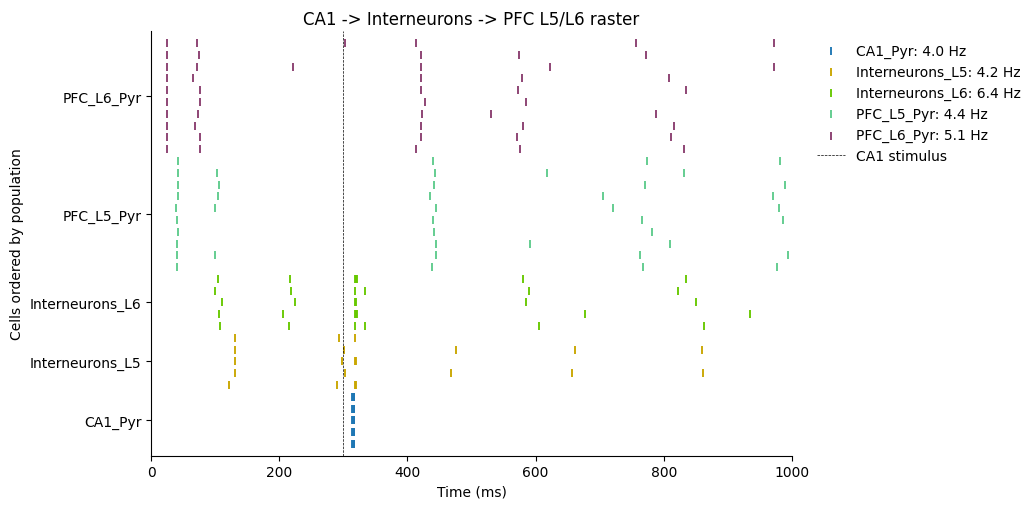


CA1_Pyr gids: [0, 1, 2, 3, 4]
  baseline_before_CA1_stim  : 0 spikes
  CA1_response              : 20 spikes

Interneurons_L5 gids: [5, 6, 7, 8, 9]
  baseline_before_CA1_stim  : 3 spikes
  CA1_response              : 7 spikes

Interneurons_L6 gids: [10, 11, 12, 13, 14]
  baseline_before_CA1_stim  : 5 spikes
  CA1_response              : 12 spikes

PFC_L5_Pyr gids: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
  baseline_before_CA1_stim  : 0 spikes
  CA1_response              : 10 spikes

PFC_L6_Pyr gids: [25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
  baseline_before_CA1_stim  : 1 spikes
  CA1_response              : 11 spikes


In [11]:
from numpy import save
import seaborn as sns
spkt = np.array(sim.simData['spkt'])
spkid = np.array(sim.simData['spkid'])

save = True  # Set to True to save figures as SVG files

def pop_gids(pop):
    return sorted(cell['gid'] for cell in sim.net.allCells if cell['tags']['pop'] == pop)


gids = {pop: pop_gids(pop) for pop in pop_order}
colors = {
    'CA1_Pyr': 'tab:blue',
    'Interneurons_L5': '#c9a600',
    'Interneurons_L6': "#67c800",
    'PFC_L5_Pyr': '#5ecb8c',
    'PFC_L6_Pyr': '#8a3f70'
}

gid_to_y = {}
y_tick_centers = []
y_tick_labels = []
y = 0
for pop in pop_order:
    start_y = y
    for gid in gids[pop]:
        gid_to_y[gid] = y
        y += 1
    y_tick_centers.append((start_y + y - 1) / 2)
    y_tick_labels.append(pop)

fig, ax = plt.subplots(figsize=(10.5, 5.2))
for pop in pop_order:
    mask = np.isin(spkid, gids[pop])
    y_values = np.array([gid_to_y[gid] for gid in spkid[mask]])
    rate_hz = mask.sum() / (len(gids[pop]) * cfg.duration / 1000.0)
    ax.scatter(spkt[mask], y_values, marker='|', s=36, linewidths=1.35,
               color=colors[pop], label=f'{pop}: {rate_hz:.1f} Hz')

ax.axvline(stim_time_ms, color='black', ls='--', lw=0.5, label='CA1 stimulus')
#ax.axvspan(*l5_silence_window, color='#5ecb8c', alpha=0.10, label='L5 transient silence')
#ax.axvspan(*l6_silence_window, color='#8a3f70', alpha=0.08, label='L6 transient silence')
ax.set_xlim(0, cfg.duration)
ax.set_ylim(-1, y)
ax.set_yticks(y_tick_centers)
ax.set_yticklabels(y_tick_labels)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Cells ordered by population')
ax.set_title('CA1 -> Interneurons -> PFC L5/L6 raster')
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left', frameon=False)
plt.tight_layout()
sns.despine()
# Save as SVG
if save:
    plt.savefig("raster_plot_BL_final2.svg", format="svg")

plt.show()




def count_spikes(pop, t0, t1):
    mask = np.isin(spkid, gids[pop]) & (spkt >= t0) & (spkt < t1)
    return int(mask.sum())

windows = {
    'baseline_before_CA1_stim': (stim_time_ms - 150.0, stim_time_ms),
    'CA1_response': (stim_time_ms, stim_time_ms + 150.0),
    #'interneuron_fast_window': (stim_time_ms + 10.0, stim_time_ms + 80.0),
    #'L5_silence_window': l5_silence_window,
    #'L6_silence_window': l6_silence_window,
    #'recovery_window': (stim_time_ms + 220.0, stim_time_ms + 350.0)
}

for pop in pop_order:
    print('\n' + pop, 'gids:', gids[pop])
    for name, (t0, t1) in windows.items():
        print(f'  {name:26s}: {count_spikes(pop, t0, t1)} spikes')

# print('\nExpected qualitative pattern: baseline random firing, CA1 activation near 300 ms, faster interneuron activity after CA1, and transient L5/L6 suppression followed by recovery.')

## Optional Somatic Voltage Traces

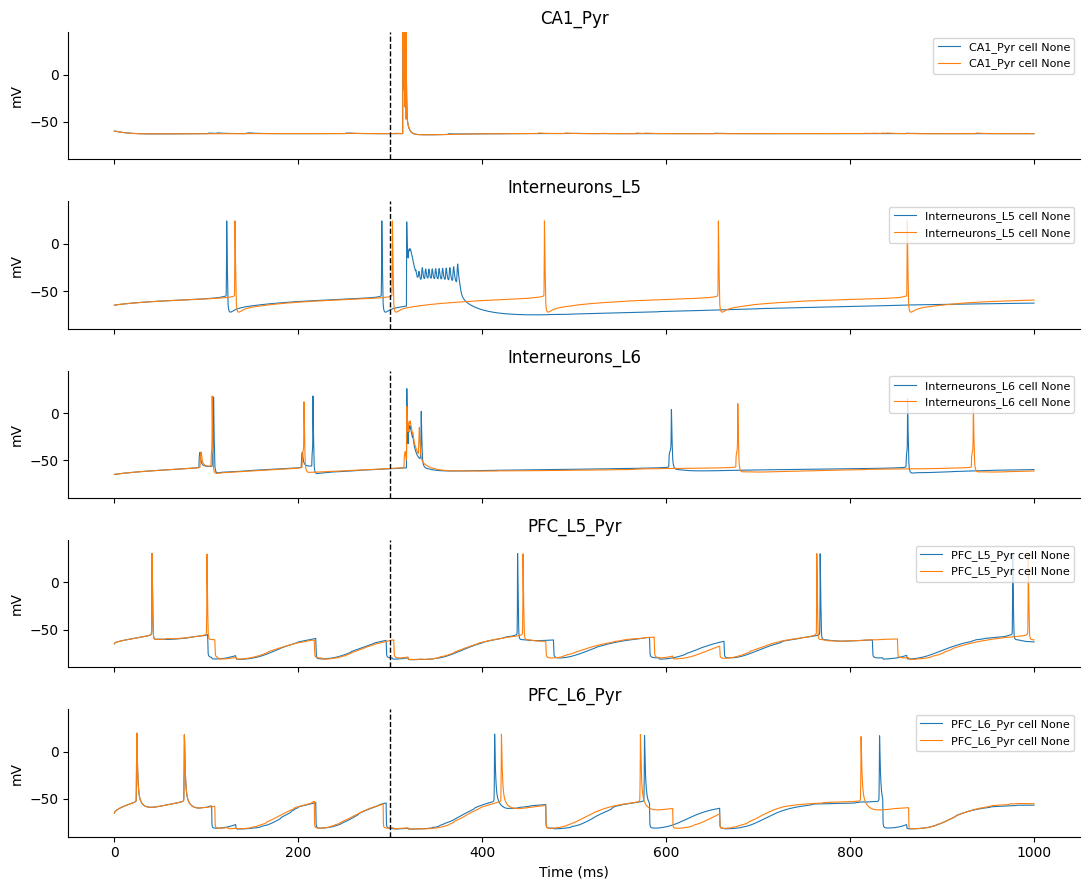

In [12]:
t = np.array(trace_records['t'])
v_records = trace_records['v']

fig, axes = plt.subplots(len(pop_order), 1, figsize=(11, 9), sharex=True)
for ax, pop in zip(axes, pop_order):
    plotted = 0
    for gid, rec in v_records.items():
        if rec['pop'] == pop and plotted < 2:
            ax.plot(t, np.array(rec['vec']), lw=0.8, label=f'{pop} cell {rec["cellLabel"]}')
            plotted += 1
    ax.axvline(stim_time_ms, color='black', ls='--', lw=1.0)
    #ax.axvspan(*l5_silence_window, color='#5ecb8c', alpha=0.08)
    #ax.axvspan(*l6_silence_window, color='#8a3f70', alpha=0.06)
    ax.set_ylabel('mV')
    ax.set_title(pop)
    ax.set_ylim([-90, 45])
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
sns.despine()
# Save as SVG
if save:
    plt.savefig("pop_cells_BL_final2.svg", format="svg")
plt.show()


